In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Carregando bases...
Base Analítica Final: 23166 linhas e 33 colunas.


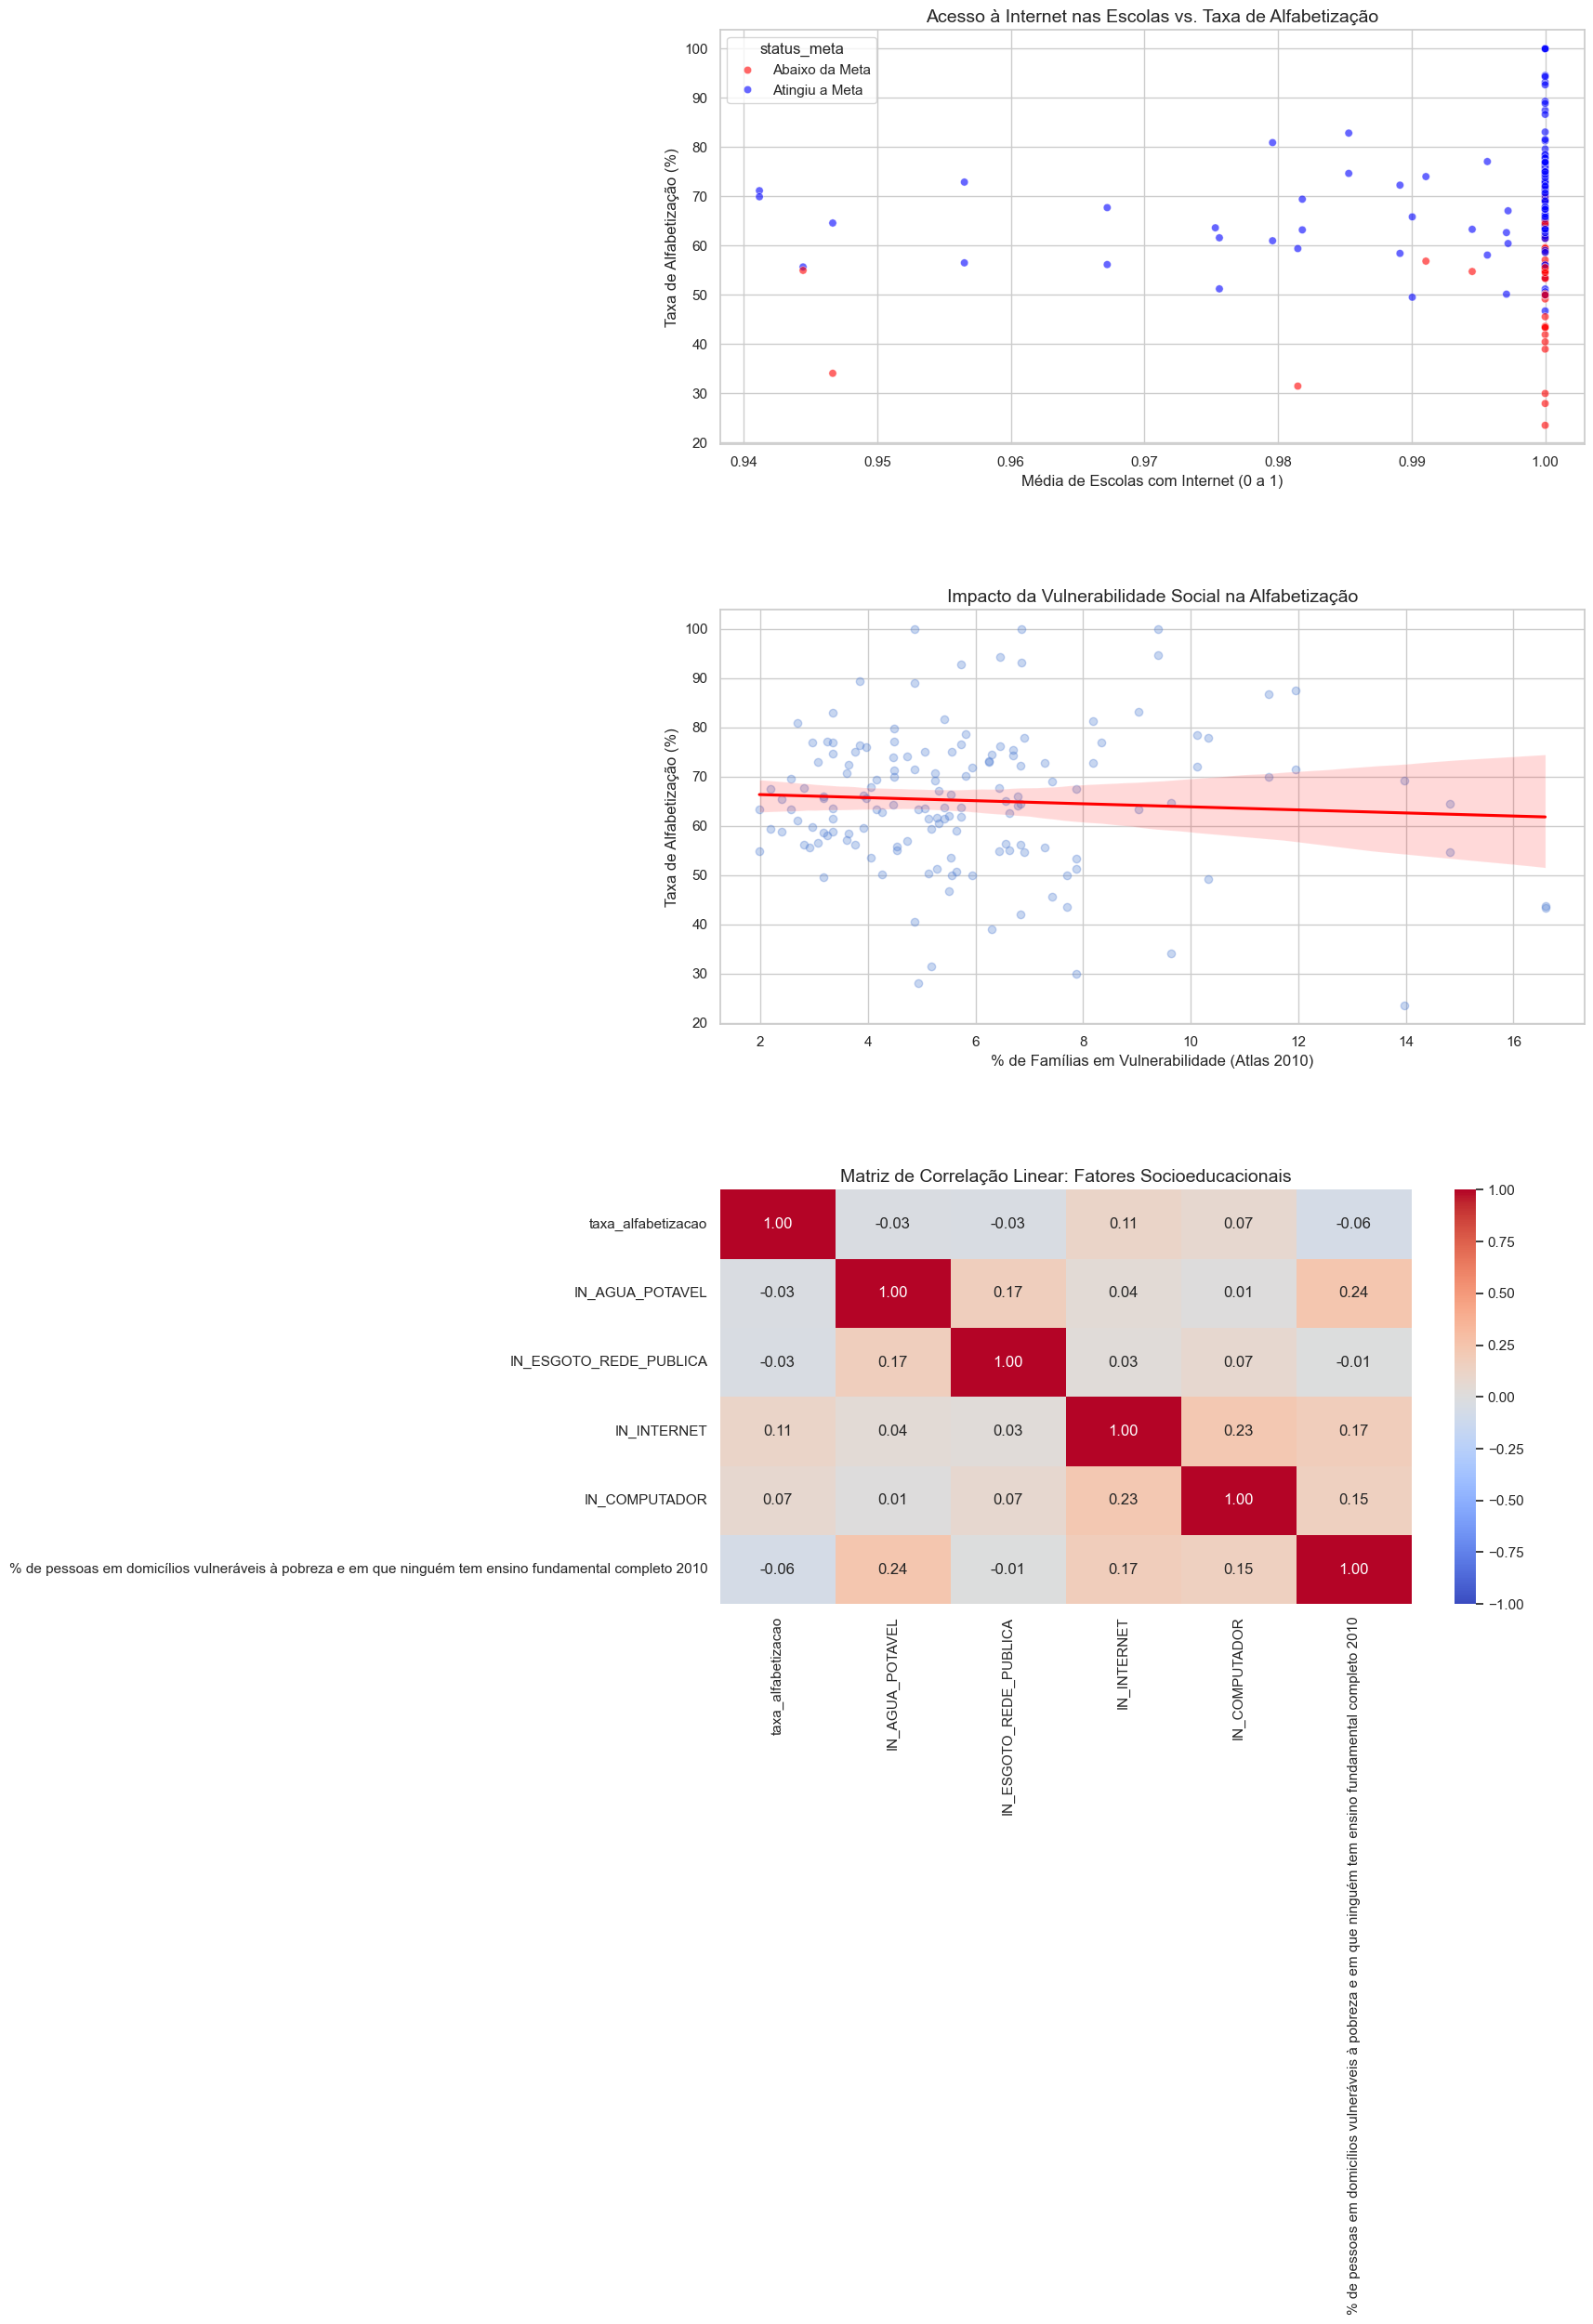

Tabela Analítica salva com sucesso! Prontos para Machine Learning.


In [4]:
# Configuração visual profissional para o storytelling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# ====================================================================
# 1. CARREGAMENTO DAS BASES LIMPAS
# ====================================================================
print("Carregando bases...")
df_gold = pd.read_parquet("gold_indicadores_alfabetizacao.parquet")
df_censo = pd.read_parquet("censo_escolar_agregado.parquet")
df_atlas = pd.read_parquet("atlas_vulnerabilidade_limpo.parquet")

# ====================================================================
# 2. CRUZAMENTO DOS DADOS (MERGE)
# ====================================================================
# Garantindo que as chaves sejam strings
df_gold['id_municipio'] = df_gold['id_municipio'].astype(str)
df_censo['id_municipio'] = df_censo['id_municipio'].astype(str)
df_atlas['id_municipio'] = df_atlas['id_municipio'].astype(str)

# 2.1 Join Gold + Censo (Por Município E Rede)
df_master = pd.merge(df_gold, df_censo, on=['id_municipio', 'rede'], how='left')

# 2.2 Join Master + Atlas (Apenas por Município, já que Atlas não tem quebra por rede)
df_master = pd.merge(df_master, df_atlas, on='id_municipio', how='left')

print(f"Base Analítica Final: {df_master.shape[0]} linhas e {df_master.shape[1]} colunas.")

# Opcional: Tratar nulos gerados pelo merge (ex: cidades sem dados no censo ou atlas)
# Para a EDA, podemos dropar. Para o ML depois, faremos imputação.
df_eda = df_master.dropna(subset=['taxa_alfabetizacao', 'IN_INTERNET', 
                                  '% de pessoas em domicílios vulneráveis à pobreza e em que ninguém tem ensino fundamental completo 2010'])


# ====================================================================
# 3. STORYTELLING VISUAL & PERGUNTAS DE NEGÓCIO (LAYOUT OTIMIZADO)
# ====================================================================
# Criando uma figura única com 3 linhas e 1 coluna
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 22))
fig.subplots_adjust(hspace=0.4) # Aumenta o espaço vertical entre os gráficos

# --- Pergunta 1 (Eixo 0) ---
sns.scatterplot(
    data=df_eda, 
    x='IN_INTERNET', 
    y='taxa_alfabetizacao', 
    hue='status_meta', 
    alpha=0.6, 
    palette={'Acima da Meta': 'green', 'Atingiu a Meta': 'blue', 'Abaixo da Meta': 'red'},
    ax=axes[0]
)
axes[0].set_title("Acesso à Internet nas Escolas vs. Taxa de Alfabetização", fontsize=14)
axes[0].set_xlabel("Média de Escolas com Internet (0 a 1)", fontsize=12)
axes[0].set_ylabel("Taxa de Alfabetização (%)", fontsize=12)

# --- Pergunta 2 (Eixo 1) ---
col_vuln = '% de pessoas em domicílios vulneráveis à pobreza e em que ninguém tem ensino fundamental completo 2010'
sns.regplot(
    data=df_eda, 
    x=col_vuln, 
    y='taxa_alfabetizacao', 
    scatter_kws={'alpha':0.3}, 
    line_kws={'color':'red'},
    ax=axes[1]
)
axes[1].set_title("Impacto da Vulnerabilidade Social na Alfabetização", fontsize=14)
axes[1].set_xlabel("% de Famílias em Vulnerabilidade (Atlas 2010)", fontsize=12)
axes[1].set_ylabel("Taxa de Alfabetização (%)", fontsize=12)

# --- Pergunta 3 (Eixo 2) ---
cols_corr = ['taxa_alfabetizacao', 'IN_AGUA_POTAVEL', 'IN_ESGOTO_REDE_PUBLICA', 
             'IN_INTERNET', 'IN_COMPUTADOR', col_vuln]
corr = df_eda[cols_corr].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title("Matriz de Correlação Linear: Fatores Socioeducacionais", fontsize=14)

plt.show()

# ====================================================================
# 4. EXPORTAR A BASE MASTER PARA A MODELAGEM
# ====================================================================
df_master.to_parquet("abt_alfabetizacao_modelagem.parquet")
print("Tabela Analítica salva com sucesso! Prontos para Machine Learning.")